# 03 · Exploratory Diagnostics and Descriptive Figures

Every figure here is built from the cached event table alone — no model is fitted, so this
stage runs in seconds and can be iterated freely.

Three of these figures are not decoration; they are the evidence for open findings in the
methodology audit that had previously been asserted only in prose:

- the **correlation heatmap** and **VIF panel** are the evidence for P2-3, *"collinearity
  is severe and largely unaddressed"*;
- the **Y1↔Y3 dependence plot** makes the `Y3 = 0 ⟺ Y1 ≥ 0` identity (P1-3) visible rather
  than merely stated;
- the **fold diagram** shows why pooled R² is measured against a compressed denominator.

All figures are written to `docs/figures/` at 300 dpi so the thesis can cite them.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403

from src.evaluation import figures as fx
fx.apply_thesis_style()

dataset = load_frame("dataset")
spec = load_json("feature_spec")
FEATURE_COLS, TARGET_COLS, TYPE_COLS = spec["FEATURE_COLS"], spec["TARGET_COLS"], spec["TYPE_COLS"]
X = dataset[FEATURE_COLS].fillna(0.0)
y = dataset[TARGET_COLS].copy()
print(f"{len(dataset)} events x {len(FEATURE_COLS)} features")


74 events x 54 features


## Target distributions

The ECDF row matters more than the histogram row. A histogram of Y3 buries its structure
inside a bin, while the ECDF shows the point mass at 0 and the point mass at the 90-day cap
as two unmistakable vertical jumps. That shape — zero-inflated and right-censored — is why
a single continuous regressor is the wrong model for Y3, and why the training-mean
predictor currently beats every fitted model on it.

saved -> docs\figures\fig_02_target_distributions.png (145 KB)
Y1_aspi_log_return     n= 74  mean=-0.0001218  median=+2.738e-05  sd=0.01581  min=-0.07534  max=+0.06927
Y2_abnormal_volume     n= 61  mean=-0.1292  median=-0.3459  sd=0.5799  min=-0.8699  max=+1.942
Y3_recovery_days       n= 74  mean=+13.59  median=+0  sd=28.99  min=+0  max=+90


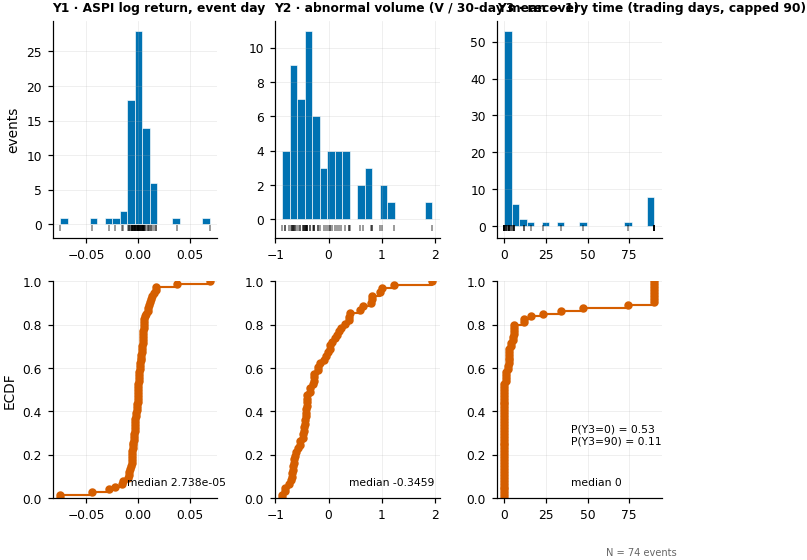

In [2]:
fig = fx.plot_target_distributions(dataset, TARGET_COLS)
fx.save_figure(fig, "fig_02_target_distributions")

for t in TARGET_COLS:
    v = pd.to_numeric(dataset[t], errors="coerce").dropna()
    print(f"{t:<22s} n={len(v):3d}  mean={v.mean():+.4g}  median={v.median():+.4g}  "
          f"sd={v.std():.4g}  min={v.min():+.4g}  max={v.max():+.4g}")


## Y3 is not an independent target

The recovery window includes the event day and the baseline is the previous close, so any
event with a non-negative event-day return "recovers" on day 0 by construction. The
contingency panel shows the consequence: the cell for *Y1 ≥ 0 and Y3 > 0* is empty. Over
half of Y3 is a mechanical restatement of the sign of Y1, so Y3 performance cannot be read
as independent evidence, and a hurdle model's first stage is close to a sign classifier.

saved -> docs\figures\fig_03_target_dependence_y1_y3.png (123 KB)


WindowsPath('F:/CSE-disaster-impact-predictor/docs/figures/fig_03_target_dependence_y1_y3.png')

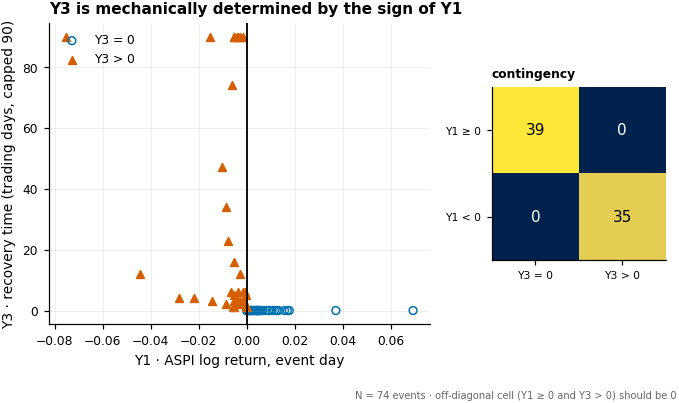

In [3]:
fig = fx.plot_target_dependence_y1_y3(dataset)
fx.save_figure(fig, "fig_03_target_dependence_y1_y3")


## Feature correlation — the evidence for P2-3

Spearman rather than Pearson, for three reasons specific to this data. `financial_damage`
is zero for 47 of 64 events with a long tail on the remaining 17, so a Pearson coefficient
there is driven by two or three observations. Y3 has point masses at both ends, against
which only a rank measure is defensible. And because Spearman is invariant to monotone
transforms, a column and its own logarithm read exactly **1.00** — not a defect but the
cleanest possible statement that the two are one variable.

Cells below the significance threshold for this sample size are greyed out. With n = 64
that threshold is |ρ| ≈ 0.25; without the mask a reader will point at a 0.3 cell and ask
what it means, when the answer is "nothing".

saved -> docs\figures\fig_04_feature_correlation_heatmap.png (550 KB)
Most redundant feature pairs (Spearman):
              feature_a               feature_b      rho          group_a
       financial_damage    log_financial_damage 1.000000  damage/severity
    population_affected log_population_affected 1.000000  damage/severity
        price_to_sma_10         price_to_ema_10 0.980748 returns/momentum
       financial_damage           damage_to_gdp 0.970114  damage/severity
   log_financial_damage           damage_to_gdp 0.970114  damage/severity
        price_to_sma_20         price_to_ema_20 0.961318 returns/momentum
         price_to_sma_5          price_to_ema_5 0.955187 returns/momentum
        price_to_ema_10         price_to_sma_20 0.942510 returns/momentum
        price_to_ema_10         price_to_ema_20 0.940792 returns/momentum
       hz_precip_mean3d        hz_districts_wet 0.940030            other
di_houses_destroyed_log   di_houses_damaged_log 0.939247            other
 

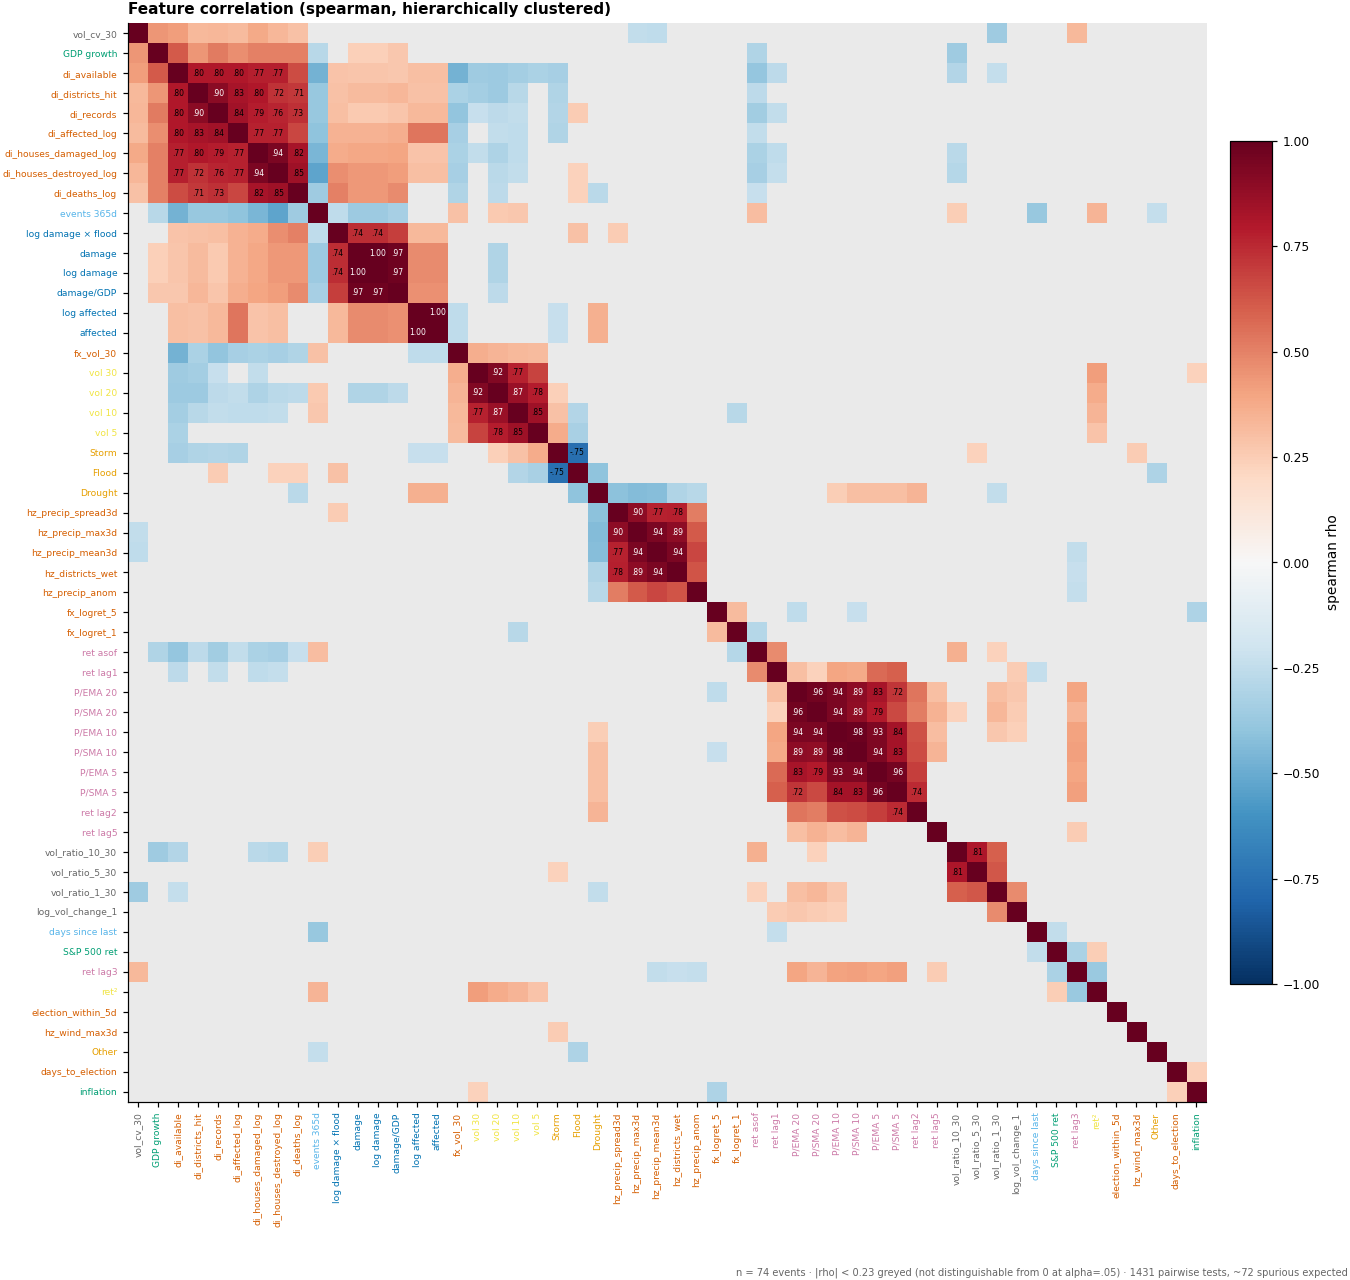

In [4]:
fig = fx.plot_feature_correlation_heatmap(X, method="spearman")
fx.save_figure(fig, "fig_04_feature_correlation_heatmap", formats=("png", "pdf"))

from src.evaluation import collinearity as col

pairs = col.top_correlated_pairs(X, top_n=12)
print("Most redundant feature pairs (Spearman):")
print(pairs[["feature_a", "feature_b", "rho", "group_a"]].to_string(index=False))


saved -> docs\figures\fig_06_collinearity_vif.png (292 KB)
condition number = 13707279918030594  (indices above 30 are the usual concern)


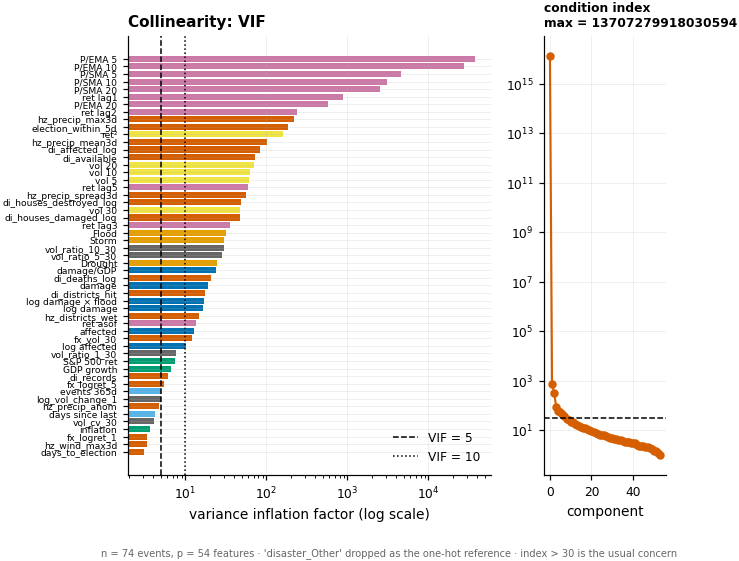

In [5]:
fig = fx.plot_vif(X)
fx.save_figure(fig, "fig_06_collinearity_vif")

ci = col.condition_indices(X)
print(f"condition number = {ci.max():.0f}  (indices above 30 are the usual concern)")


### The pre-declared redundancy rule

Stated before any model was scored under it, so applying it cannot be selection on test
performance: **within any group of features whose pairwise |ρ| exceeds 0.95, keep the
single most primitive member — the one with the fewest derivation steps from a raw
measurement — and drop the rest.** Ties break alphabetically so the outcome is
deterministic.

The rule never consults a target, a fold or a score. Whatever it does to the metrics is
reported either way.

In [6]:
keep, drop, detail = col.redundant_drop_set(X, threshold=0.95)
print(f"Rule at |rho| >= 0.95: keep {len(keep)} features, drop {len(drop)}.\n")
if len(detail):
    print(detail.to_string(index=False))
else:
    print("No feature pair exceeds the threshold.")

save_json({"keep": keep, "drop": drop, "threshold": 0.95,
           "rule": "within a >=0.95 correlated group keep the least-derived member"},
          "collinearity_rule")


Rule at |rho| >= 0.95: keep 48 features, drop 6.

                dropped                kept  rho_with_kept            group
          damage_to_gdp    financial_damage       0.970114  damage/severity
   log_financial_damage    financial_damage       1.000000  damage/severity
log_population_affected population_affected       1.000000  damage/severity
         price_to_sma_5      price_to_ema_5       0.955187 returns/momentum
        price_to_sma_10     price_to_ema_10       0.980748 returns/momentum
        price_to_sma_20     price_to_ema_20       0.961318 returns/momentum
cached collinearity_rule.json


WindowsPath('F:/CSE-disaster-impact-predictor/disaster_finance_predictor/artifacts/collinearity_rule.json')

## Walk-forward geometry, and why R² is measured against a compressed denominator

The two largest shocks in the sample — the 2004-12-26 tsunami and the 2005-11-21 flood —
are events 7 and 8, which places them permanently inside fold 0's *training* window. They
appear in no test fold. The held-out folds therefore carry markedly less variance than the
full sample, and since R² scores against the test set's own mean, that compression is part
of why pooled R² is negative. It also means the reported R² is **conservative**, not
flattering.

saved -> docs\figures\fig_09_walk_forward_folds.png (155 KB)
target                   full sigma   test sigma   ratio
Y1_aspi_log_return         0.015807      0.01363    0.86
Y2_abnormal_volume          0.57988      0.54111    0.93
Y3_recovery_days             28.985       29.342    1.01


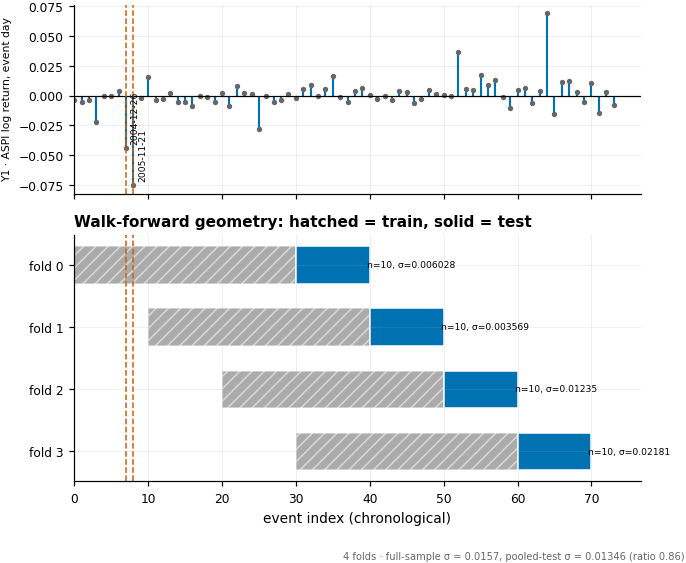

In [7]:
splits = load_object("splits")
fig = fx.plot_walk_forward_folds(splits, dataset, y)
fx.save_figure(fig, "fig_09_walk_forward_folds", formats=("png", "pdf"))

import numpy as np

test_idx = np.concatenate([np.asarray(s.test_index) for s in splits])
print(f"{'target':<22s} {'full sigma':>12s} {'test sigma':>12s} {'ratio':>7s}")
for t in TARGET_COLS:
    v = pd.to_numeric(y[t], errors="coerce")
    full, test = v.std(), v.iloc[test_idx].std()
    print(f"{t:<22s} {full:12.5g} {test:12.5g} {test / full:7.2f}")


## What the damage features actually measure

Most Sri Lankan EM-DAT records carry no damage estimate, and the loader zero-fills them.
The damage block therefore behaves substantially as an indicator of **EM-DAT reporting
coverage** — itself correlated with severity and recency — rather than as a clean severity
measure. The interaction term `log_damage_x_flood` rests on an even narrower base.

In [8]:
if "damage_source" in dataset.columns:
    print(dataset["damage_source"].value_counts().to_string())
    has = int((dataset["financial_damage"] > 0).sum())
    print(f"\nevents with a real damage figure: {has}/{len(dataset)}")
    if "disaster_Flood" in dataset.columns:
        supp = int(((dataset["financial_damage"] > 0) & (dataset["disaster_Flood"] == 1)).sum())
        print(f"of which floods -- the entire support of log_damage_x_flood: {supp}")

print("\nExported figures:")
print(fx.figure_manifest().to_string(index=False))


damage_source
missing_zero_filled          56
emdat_cpi_adjusted           17
emdat_unadjusted_fallback     1

events with a real damage figure: 18/74
of which floods -- the entire support of log_damage_x_flood: 12

Exported figures:
                              filename  kb
       fig_02_target_distributions.png 145
    fig_03_target_dependence_y1_y3.png 123
fig_04_feature_correlation_heatmap.png 550
           fig_06_collinearity_vif.png 292
         fig_09_walk_forward_folds.png 155
         fig_11_conformal_coverage.png 110
                fig_14_roc_with_ci.png 188
    fig_17_model_vs_naive_baseline.png 122
 fig_18_skill_forest_vs_naive_zero.png  85
fig_18b_skill_forest_vs_train_mean.png  85
          fig_19_pred_vs_actual_y1.png 148
          fig_19_pred_vs_actual_y2.png 178
          fig_19_pred_vs_actual_y3.png 130
            fig_24_overfitting_gap.png 163
  fig_31_sector_response_and_skill.png 221
